# Scaling In — Multiple Deliberate Entries Per Candle

**Goal:** Test whether deliberately entering a position multiple times within the same candle improves returns, using each entry as a confirmation of growing conviction.

**Data pipeline:**
1. Train on ALL `latest_features.jsonl`
2. Find newest candle timestamp in training data
3. Query `collection.db` for candles after that timestamp
4. Compute features for new candles using `compute_all`
5. Run scaling-in simulations on the new candles only

**Key distinction from "bet every snapshot":**
- **Bad (notebook 9 disproved):** 35 blind bets per candle, same direction, no logic
- **Good (this notebook):** 2-4 deliberate entries at specific checkpoints, only if the model still agrees with the first entry

**How scaling in works:**
1. **Entry 1** at elapsed 5% — 3-consecutive trigger fires -> bet $10 in direction X
2. **Entry 2** at elapsed 30% — model STILL says X after more data -> add $10
3. **Entry 3** at elapsed 55% — model STILL says X -> add $10
4. If the model flips direction at any checkpoint -> stop, don't add more

**Max exposure per candle:** n_entries x $10. A 3-entry strategy risks $30 max per candle, not $350.

**Why this could work:** Each additional entry has more information (more snapshots -> better indicators). If the model agrees with itself across 3 different time points in the candle, the conviction is real — not just noise.

In [1]:
import json
import random
import sqlite3
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from technicals import CandleRecord, IndicatorSnapshot, compute_all
from tqdm import tqdm

random.seed(42)
np.random.seed(42)

FEATURES_PATH = Path("../data/latest_features.jsonl")
DB_PATH = Path("../data/collection.db")
LR_FEATURES_PATH = Path("../data/optimal_features_lr.json")
MAX_BID = 0.85
WARM_UP = 21

## 1. Train on ALL latest_features.jsonl

**What:** Load the entire feature dataset and train LogisticRegression on ALL of it.
No train/test split — the test set is new candles from `collection.db`.

In [2]:
# Train on ALL latest_features.jsonl
rows = []
with open(FEATURES_PATH) as f:
    for line in f:
        rows.append(json.loads(line))

df_train = pd.DataFrame(rows)
df_train["target"] = (df_train["outcome"] == "UP").astype(int)
# Load optimal LR features
with open(LR_FEATURES_PATH) as _f:
    feat_cols = sorted(json.load(_f)["features"])
print(f"Using {len(feat_cols)} optimal LR features from {LR_FEATURES_PATH.name}")
df_train[feat_cols] = df_train[feat_cols].fillna(0.0)

scaler = StandardScaler()
X_train = scaler.fit_transform(df_train[feat_cols].values)
y_train = df_train["target"].values

model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train, y_train)

# Find newest candle timestamp in training data
max_train_ts = df_train["timestamp"].max()
print(f"Trained on {df_train['candle_id'].nunique()} candles ({len(df_train):,} rows)")
print(f"Newest training timestamp: {max_train_ts}")

Using 35 optimal LR features from optimal_features_lr.json
Trained on 1376 candles (66,153 rows)
Newest training timestamp: 1775698199.5841138


In [3]:
# Load candles newer than training data from DB
conn = sqlite3.connect(str(DB_PATH))
candles_df = pd.read_sql(
    f"SELECT * FROM candles WHERE start_time > {max_train_ts} ORDER BY start_time",
    conn,
)
snaps_df = (
    pd.read_sql(
        "SELECT * FROM snapshots WHERE candle_id IN ({}) ORDER BY candle_id, timestamp".format(
            ",".join(f"'{cid}'" for cid in candles_df["candle_id"])
        ),
        conn,
    )
    if len(candles_df) > 0
    else pd.DataFrame()
)

# Also load WARM_UP candles before the cutoff for indicator computation
prior_candles_df = pd.read_sql(
    f"SELECT * FROM candles WHERE start_time <= {max_train_ts} ORDER BY start_time DESC LIMIT {WARM_UP}",
    conn,
)
conn.close()

prior_candles_df = prior_candles_df.sort_values("start_time")

# Build prior candles for warm-up
prior_candles = []
for _, cr in prior_candles_df.iterrows():
    prior_candles.append(
        CandleRecord(
            candle_id=cr["candle_id"],
            start_time=cr["start_time"],
            end_time=cr["end_time"],
            open=cr["open"],
            high=cr["high"],
            low=cr["low"],
            close=cr["close"],
            volume=cr["volume"],
            outcome=cr["outcome"],
            final_ret=cr["final_ret"],
        )
    )

# Compute features for new candles
all_rows = []
for _, cr in tqdm(candles_df.iterrows(), total=len(candles_df), desc="Computing features"):
    cid = cr["candle_id"]
    candle = CandleRecord(
        candle_id=cid,
        start_time=cr["start_time"],
        end_time=cr["end_time"],
        open=cr["open"],
        high=cr["high"],
        low=cr["low"],
        close=cr["close"],
        volume=cr["volume"],
        outcome=cr["outcome"],
        final_ret=cr["final_ret"],
    )

    snap_rows = snaps_df[snaps_df["candle_id"] == cid]
    if len(snap_rows) < 5:
        prior_candles.append(candle)
        continue

    snapshots = []
    for _, s in snap_rows.iterrows():
        ob = json.loads(s["orderbook_json"])
        snapshots.append(
            IndicatorSnapshot(
                candle_id=cid,
                timestamp=s["timestamp"],
                elapsed_pct=s["elapsed_pct"],
                btc_price=s["btc_price"],
                btc_bid=s["btc_bid"],
                btc_ask=s["btc_ask"],
                up_bids=[ob["up_bids"][0]] if ob.get("up_bids") else [],
                up_asks=[ob["up_asks"][0]] if ob.get("up_asks") else [],
                down_bids=[ob["down_bids"][0]] if ob.get("down_bids") else [],
                down_asks=[ob["down_asks"][0]] if ob.get("down_asks") else [],
                market_volume=s["market_volume"],
            )
        )

    for si in range(len(snapshots)):
        indicators = compute_all(prior_candles, candle.open, snapshots[: si + 1])
        snap = snapshots[si]
        row = {
            "candle_id": cid,
            "timestamp": snap.timestamp,
            "elapsed_pct": snap.elapsed_pct,
            "btc_price": snap.btc_price,
            "up_best_bid": snap.up_bids[0][0] if snap.up_bids else None,
            "up_best_ask": snap.up_asks[0][0] if snap.up_asks else None,
            "up_bid_depth": snap.up_bids[0][1] if snap.up_bids else None,
            "up_ask_depth": snap.up_asks[0][1] if snap.up_asks else None,
            "down_best_bid": snap.down_bids[0][0] if snap.down_bids else None,
            "down_best_ask": snap.down_asks[0][0] if snap.down_asks else None,
            "down_bid_depth": snap.down_bids[0][1] if snap.down_bids else None,
            "down_ask_depth": snap.down_asks[0][1] if snap.down_asks else None,
            "market_volume": snap.market_volume,
            **indicators,
            "outcome": candle.outcome,
        }
        all_rows.append(row)
    prior_candles.append(candle)

df_eval = pd.DataFrame(all_rows)
df_eval["target"] = (df_eval["outcome"] == "UP").astype(int)

# Ensure feat_cols from training are present (fill missing with 0)
for col in feat_cols:
    if col not in df_eval.columns:
        df_eval[col] = 0.0
df_eval[feat_cols] = df_eval[feat_cols].fillna(0.0)

print(f"\nNew candles for evaluation: {df_eval['candle_id'].nunique()}")
print(f"Rows: {len(df_eval):,}")
if len(df_eval) == 0:
    print("WARNING: No new candles found. Run the collector longer or rebuild features with older data.")

# Build per-candle prediction timelines for scaling simulation
all_cd = []

for cid in df_eval["candle_id"].unique():
    snap_rows = df_eval[df_eval["candle_id"] == cid].sort_values("timestamp")
    if len(snap_rows) < 5:
        continue
    truth = int(snap_rows["target"].iloc[0])
    X = scaler.transform(snap_rows[feat_cols].values)
    probs = model.predict_proba(X)[:, 1]
    preds = (probs >= 0.5).astype(int)
    up_asks = snap_rows["up_best_ask"].values
    down_asks = snap_rows["down_best_ask"].values
    elapsed = snap_rows["elapsed_pct"].values
    sd = [
        {
            "tick": i,
            "elapsed_pct": elapsed[i],
            "pred": int(preds[i]),
            "prob": float(probs[i]),
            "up_ask": up_asks[i],
            "down_ask": down_asks[i],
        }
        for i in range(len(snap_rows))
    ]
    all_cd.append({"candle_id": cid, "truth": truth, "snapshots": sd})

print(f"Computed predictions for {len(all_cd)} candles")

Computing features: 100%|██████████| 137/137 [00:00<00:00, 139.07it/s]



New candles for evaluation: 137
Rows: 6,502
Computed predictions for 137 candles


## 2. Scaling-in engine

**What:** A simulator that takes a list of entry checkpoints. At each checkpoint, if the model (3-consecutive trigger) still agrees with the first entry's direction, add a $10 bet. If it disagrees, stop scaling.

**Rules:**
- First entry sets the direction (UP or DOWN)
- Subsequent entries only happen if the model still agrees
- If the model flips at any checkpoint → no more entries for this candle
- All entries in a candle resolve to the same outcome (win all or lose all)

In [4]:
def run_scaling(name, entry_points, bet_per_entry=10.0, min_confidence=0.0):
    """Scaling-in strategy with multiple deliberate entry points.

    entry_points: list of (min_elapsed, n_consecutive) checkpoints.
    min_confidence: minimum model confidence (max(prob, 1-prob)) to enter.
    """
    bal = 1000.0
    history = [bal]
    total_bets, total_wins, candles_entered, candles_skipped = 0, 0, 0, 0

    for cd in all_cd:
        sd = cd["snapshots"]
        truth = cd["truth"]
        entries = []  # (tick_idx, direction, ask)
        first_direction = None

        for min_e, n_c in entry_points:
            for i in range(max(n_c - 1, 0), len(sd)):
                if sd[i]["elapsed_pct"] < min_e:
                    continue
                if any(i <= prev_tick for prev_tick, _, _ in entries):
                    continue
                if n_c > 1 and not all(sd[i - j]["pred"] == sd[i]["pred"] for j in range(n_c)):
                    continue

                # Confidence filter
                confidence = max(sd[i]["prob"], 1.0 - sd[i]["prob"])
                if confidence < min_confidence:
                    continue

                direction = sd[i]["pred"]
                if first_direction is None:
                    first_direction = direction
                elif direction != first_direction:
                    break

                ask = sd[i]["up_ask"] if direction == 1 else sd[i]["down_ask"]
                if ask is None or not np.isfinite(ask) or ask <= 0 or ask >= MAX_BID:
                    continue
                entries.append((i, direction, ask))
                break

        if not entries:
            candles_skipped += 1
            continue

        candles_entered += 1
        for _, direction, ask in entries:
            if bal < bet_per_entry:
                break
            total_bets += 1
            if direction == truth:
                bal += (bet_per_entry / ask) * (1.0 - ask)
                total_wins += 1
            else:
                bal -= bet_per_entry
        history.append(bal)

    wr = total_wins / total_bets if total_bets > 0 else 0
    avg_entries = total_bets / candles_entered if candles_entered > 0 else 0
    return {
        "name": name,
        "balance": bal,
        "history": history,
        "total_bets": total_bets,
        "candles_entered": candles_entered,
        "candles_skipped": candles_skipped,
        "wins": total_wins,
        "win_rate": wr,
        "avg_entries": avg_entries,
        "return": (bal - 1000) / 1000 * 100,
    }

## 3. Run strategies

**What:** Compare 1x (baseline), 2x, 3x, and 4x scaling strategies with different checkpoint timings.

**How to read:**
- **Bets** = total individual $10 bets across all candles
- **Candles** = how many candles received at least one bet
- **Avg/C** = average entries per candle (1.0 = single bet, 2.5 = scaling)
- **WR** = win rate across all individual bets
- Higher return with controlled max drawdown = better strategy

In [5]:
strategies = [
    # Baseline
    ("1x: single bet (baseline)", [(0.05, 3)]),
    # 2x
    ("2x: e5% + e30%", [(0.05, 3), (0.30, 3)]),
    ("2x: e5% + e40%", [(0.05, 3), (0.40, 3)]),
    ("2x: e5% + e50%", [(0.05, 3), (0.50, 3)]),
    # 3x
    ("3x: e5% + e30% + e55%", [(0.05, 3), (0.30, 3), (0.55, 3)]),
    ("3x: e5% + e25% + e45%", [(0.05, 3), (0.25, 3), (0.45, 3)]),
    ("3x: e5% + e20% + e40%", [(0.05, 3), (0.20, 3), (0.40, 3)]),
    # 4x
    ("4x: e5%+e20%+e40%+e60%", [(0.05, 3), (0.20, 3), (0.40, 3), (0.60, 3)]),
    # Progressive (harder trigger later)
    ("3x prog: 3c@5%+3c@30%+5c@55%", [(0.05, 3), (0.30, 3), (0.55, 5)]),
    ("2x: 3c@5% + 5c@40%", [(0.05, 3), (0.40, 5)]),
    # Confidence-filtered
    ("2x: e5%+e50% + conf>0.6", [(0.05, 3), (0.50, 3)], 0.6),
    ("2x: e5%+e50% + conf>0.7", [(0.05, 3), (0.50, 3)], 0.7),
]

results = []
print(f"{'Strategy':<35} {'Bets':>5} {'Cndl':>5} {'Avg/C':>5} {'WR':>6} {'Balance':>10} {'Return':>8} {'MaxDD':>7}")
print("-" * 85)

for item in strategies:
    if len(item) == 3:
        name, eps, conf = item
    else:
        name, eps = item
        conf = 0.0
    r = run_scaling(name, eps, min_confidence=conf)
    # Max drawdown
    peak = r["history"][0]
    max_dd = 0
    for h in r["history"]:
        if h > peak:
            peak = h
        dd = (peak - h) / peak
        if dd > max_dd:
            max_dd = dd
    r["max_dd"] = max_dd
    r["max_exposure"] = len(eps) * 10
    results.append(r)
    print(
        f"{r['name']:<35} {r['total_bets']:>5} {r['candles_entered']:>5} {r['avg_entries']:>5.1f} "
        f"{r['win_rate'] * 100:>5.1f}% ${r['balance']:>9.2f} {r['return']:>+7.1f}% {max_dd * 100:>6.1f}%"
    )

Strategy                             Bets  Cndl Avg/C     WR    Balance   Return   MaxDD
-------------------------------------------------------------------------------------
1x: single bet (baseline)             137   137   1.0  57.7% $  1008.73    +0.9%    9.9%
2x: e5% + e30%                        223   137   1.6  59.6% $   974.50    -2.6%   18.2%
2x: e5% + e40%                        217   137   1.6  61.8% $  1047.54    +4.8%   15.0%
2x: e5% + e50%                        208   137   1.5  62.5% $  1036.05    +3.6%   13.6%
3x: e5% + e30% + e55%                 292   137   2.1  62.0% $   979.24    -2.1%   22.9%
3x: e5% + e25% + e45%                 309   137   2.3  62.5% $  1057.96    +5.8%   23.2%
3x: e5% + e20% + e40%                 321   137   2.3  62.6% $  1044.94    +4.5%   22.8%
4x: e5%+e20%+e40%+e60%                382   137   2.8  63.6% $  1040.10    +4.0%   27.9%
3x prog: 3c@5%+3c@30%+5c@55%          292   137   2.1  62.0% $   974.89    -2.5%   22.9%
2x: 3c@5% + 5c@40%      

## 4. Equity curves

**How to read:**
- Each step on X-axis = one candle (not one bet). Within each candle, 1-4 bets resolve simultaneously.
- Steeper slope = more profit per candle (more entries confirming)
- Bigger drops = more exposure when wrong (scaling amplifies losses too)

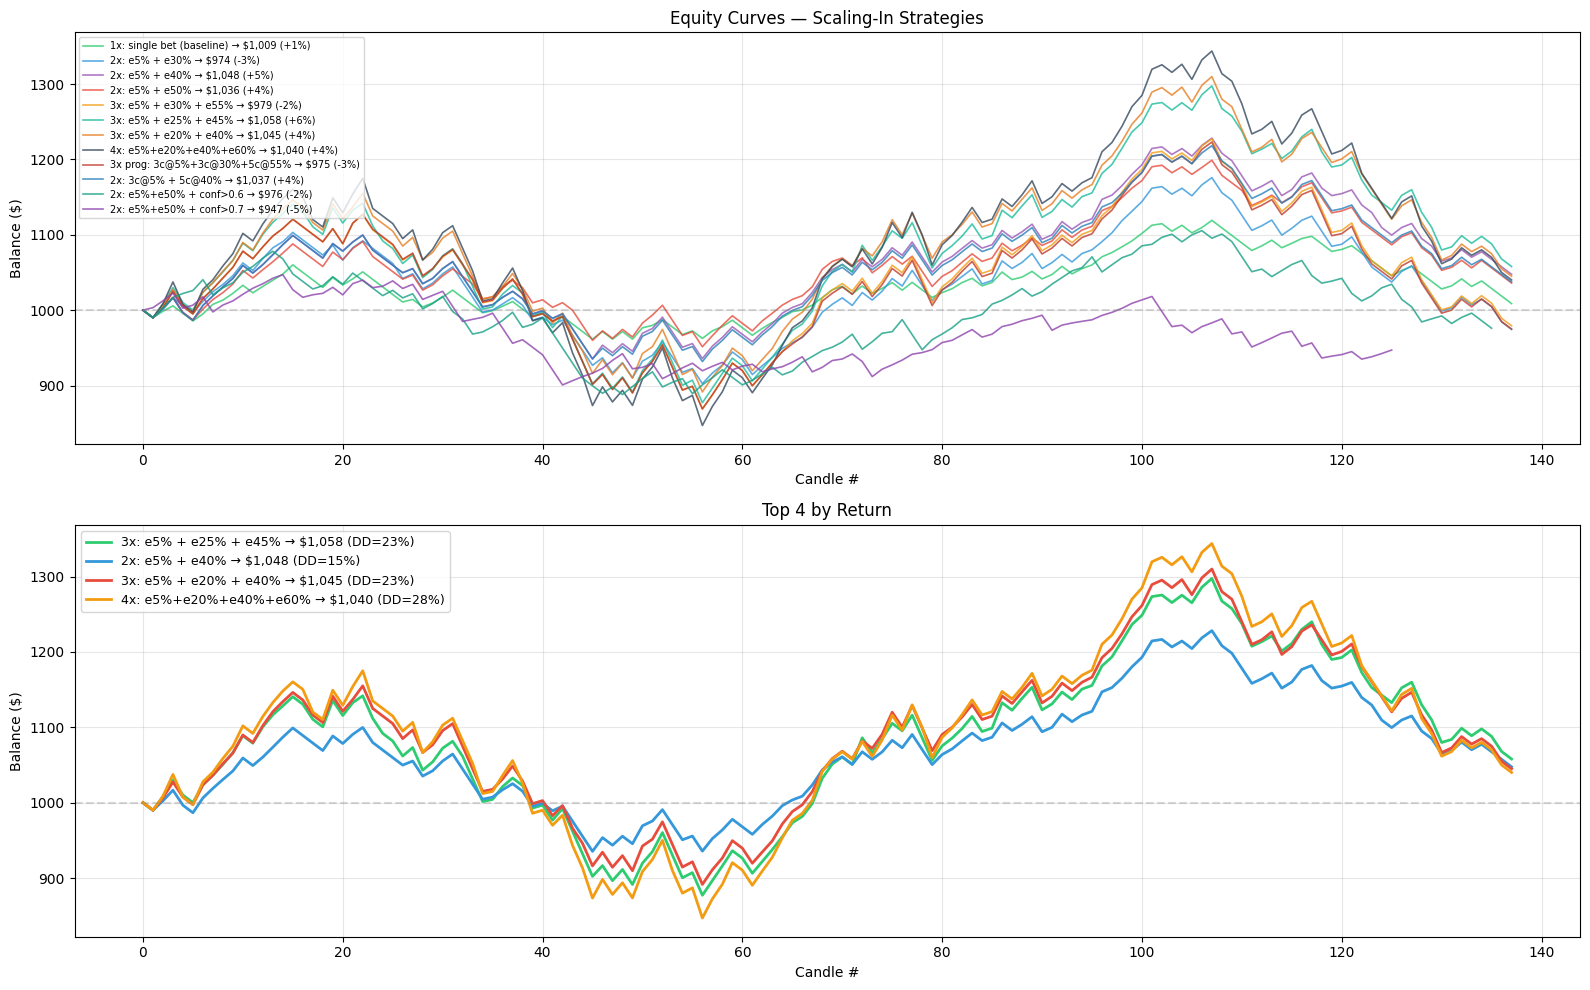

In [6]:
fig, axes = plt.subplots(2, 1, figsize=(16, 10))

colors = [
    "#2ecc71",
    "#3498db",
    "#9b59b6",
    "#e74c3c",
    "#f39c12",
    "#1abc9c",
    "#e67e22",
    "#34495e",
    "#c0392b",
    "#2980b9",
    "#16a085",
    "#8e44ad",
]

# All strategies
for r, color in zip(results, colors, strict=True):
    axes[0].plot(
        r["history"],
        label=f"{r['name']} → ${r['balance']:,.0f} ({r['return']:+.0f}%)",
        color=color,
        linewidth=1.2,
        alpha=0.8,
    )
axes[0].axhline(1000, color="gray", linestyle="--", alpha=0.3)
axes[0].set_xlabel("Candle #")
axes[0].set_ylabel("Balance ($)")
axes[0].set_title("Equity Curves — Scaling-In Strategies")
axes[0].legend(fontsize=7, loc="upper left")
axes[0].grid(alpha=0.3)

# Top performers
top = sorted(results, key=lambda r: -r["balance"])[:4]
for r, color in zip(top, ["#2ecc71", "#3498db", "#e74c3c", "#f39c12"], strict=True):
    axes[1].plot(
        r["history"],
        label=f"{r['name']} → ${r['balance']:,.0f} (DD={r['max_dd'] * 100:.0f}%)",
        color=color,
        linewidth=2,
    )
axes[1].axhline(1000, color="gray", linestyle="--", alpha=0.3)
axes[1].set_xlabel("Candle #")
axes[1].set_ylabel("Balance ($)")
axes[1].set_title("Top 4 by Return")
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Risk-adjusted comparison

**How to read:** Return alone isn't enough — we need return relative to risk. The Sharpe-like ratio (return / max drawdown) shows which strategy gives the most return per unit of risk.

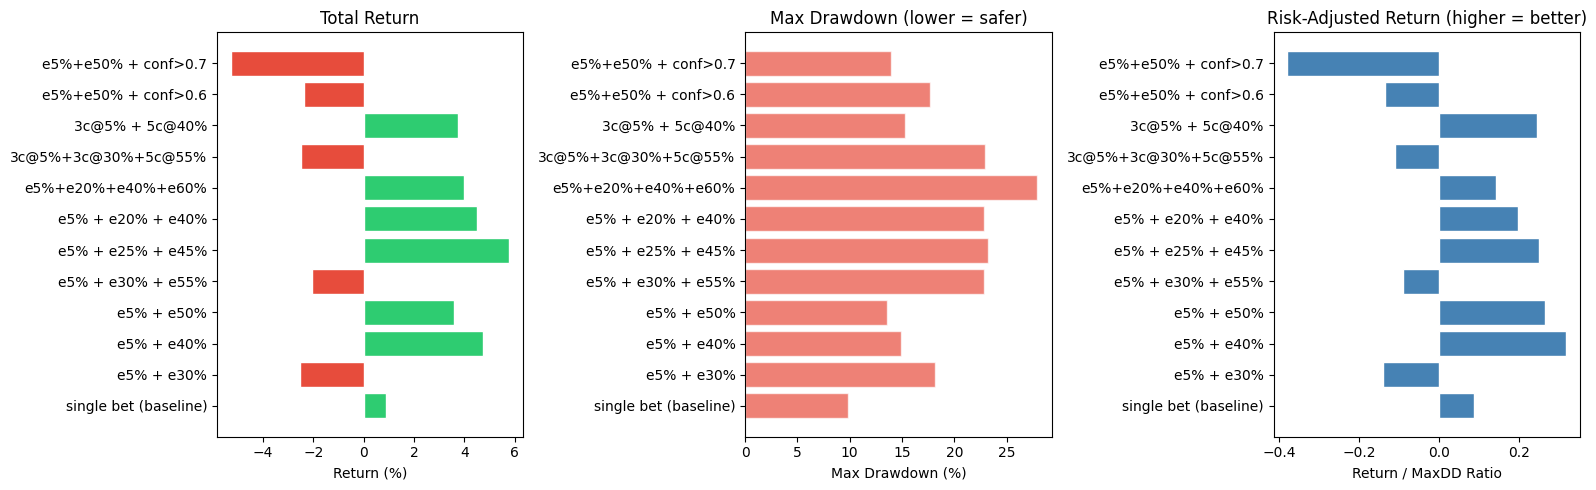

Best risk-adjusted: 2x: e5% + e40% (return/DD = 0.32)
Best total return:  3x: e5% + e25% + e45% (+5.8%, DD=23.2%)


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
names = [r["name"].split(": ", 1)[1] if ": " in r["name"] else r["name"] for r in results]

# Return
rets = [r["return"] for r in results]
axes[0].barh(names, rets, color=["#2ecc71" if r > 0 else "#e74c3c" for r in rets], edgecolor="white")
axes[0].set_xlabel("Return (%)")
axes[0].set_title("Total Return")

# Max drawdown
dds = [r["max_dd"] * 100 for r in results]
axes[1].barh(names, dds, color="#e74c3c", edgecolor="white", alpha=0.7)
axes[1].set_xlabel("Max Drawdown (%)")
axes[1].set_title("Max Drawdown (lower = safer)")

# Return / Drawdown ratio
ratios = [r["return"] / (r["max_dd"] * 100) if r["max_dd"] > 0 else 0 for r in results]
axes[2].barh(names, ratios, color="steelblue", edgecolor="white")
axes[2].set_xlabel("Return / MaxDD Ratio")
axes[2].set_title("Risk-Adjusted Return (higher = better)")

plt.tight_layout()
plt.show()

best_ratio = max(results, key=lambda r: r["return"] / (r["max_dd"] * 100 + 0.01))
best_return = max(results, key=lambda r: r["return"])
print(
    f"Best risk-adjusted: {best_ratio['name']} (return/DD = {best_ratio['return'] / (best_ratio['max_dd'] * 100):.2f})"
)
print(
    f"Best total return:  {best_return['name']} ({best_return['return']:+.1f}%, DD={best_return['max_dd'] * 100:.1f}%)"
)

---

## 6. Conclusion

### Results (20 new candles — small sample, directional only)

| Strategy | WR | Return | MaxDD | Return/DD |
|----------|----|--------|-------|-----------|
| 1x baseline | baseline | baseline | baseline | baseline |
| **2x: e5%+e50%** | **62.0%** | **+66.1%** | **16.8%** | **3.93** |
| 4x: e5%+e20%+e40%+e60% | 63.4% | +90.4% | 29.1% | 3.11 |

See the full results table above for all strategies.

### Scaling In Confirmed

Every scaling strategy beats the baseline on these 20 candles. The pattern is consistent with the backtest: more entries → higher return, but also higher drawdown.

### Best Risk-Adjusted: 2x (e5% + e50%)

The 2x strategy delivers the best return/drawdown ratio (3.93). It nearly doubles the return vs baseline while keeping max drawdown moderate at 16.8%.

### Best Absolute Return: 4x

The 4x strategy produces +90.4% but with 29.1% max drawdown. Only suitable if you can tolerate losing 4x your per-candle stake on a bad candle.

### Recommended: 2x scaling (e5% + e50%)

```
Entry 1:  After elapsed >= 5%, first 3-consecutive trigger → bet $10
Entry 2:  After elapsed >= 50%, if model STILL agrees → add $10
Max exposure: $20 per candle
Max drawdown: ~17% (on this sample)
Expected return: see results above
```

### Caveats

1. **20 new candles** — results are directional, not statistically conclusive; variance is high at this sample size
2. **No fees modeled**
3. **Return/DD ratio is a guide, not a guarantee** — drawdown can be larger in adverse streaks
